In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df_res_latte_drifter_sat = pd.read_pickle('df_res_latte_drifter_sat.pkl')
df_res_latte_drifter = pd.read_pickle('df_res_latte_drifter.pkl')
df_res_latte_drifter['Rc'] = np.nan
df_res_latte_drifter['R2'] = np.nan
df_res_doppio_num = pd.read_pickle('df_res_doppio_num.pkl')


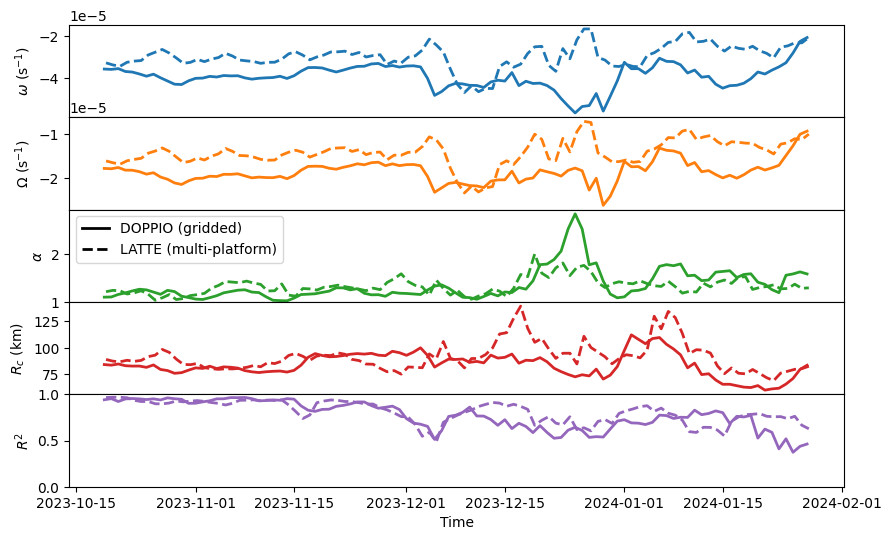

In [2]:
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
lw = 2

styles = ['-', '--']
labels = ['DOPPIO gridded data', 'LATTE mult-platform']
for k, df in enumerate([df_res_doppio_num, df_res_latte_drifter_sat]):

    axs[0].plot(df.time, df.w, color=clrs(0), lw=lw, ls=styles[k])
    axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')
    
    axs[1].plot(df.time, df.Omega, color=clrs(1), lw=lw, ls=styles[k])
    axs[1].set_ylabel(r'$\Omega$ (s$^{-1}$)')
    
    axs[2].plot(df.time, df.alpha, color=clrs(2), lw=lw, ls=styles[k])
    axs[2].set_ylabel(r'$\alpha$')
    axs[2].set_ylim(1, None)
    
    axs[3].plot(df.time, df.Rc/1e3, color=clrs(3), lw=lw, ls=styles[k])
    axs[3].set_ylabel(r'$R_c$ (km)')
    
    axs[4].plot(df.time, df.R2, color=clrs(4), lw=lw, ls=styles[k])
    axs[4].set_ylabel(r'$R^2$')
    axs[4].set_xlabel('Time')
    axs[4].set_ylim(0,1)

axs[2].plot([np.nan, np.nan], [np.nan, np.nan], lw=lw, ls='-', label='DOPPIO (gridded)', color='k')
axs[2].plot([np.nan, np.nan], [np.nan, np.nan], lw=lw, ls='--', label='LATTE (multi-platform)', color='k')
axs[2].legend(loc='upper left')

fig.subplots_adjust(hspace=0)



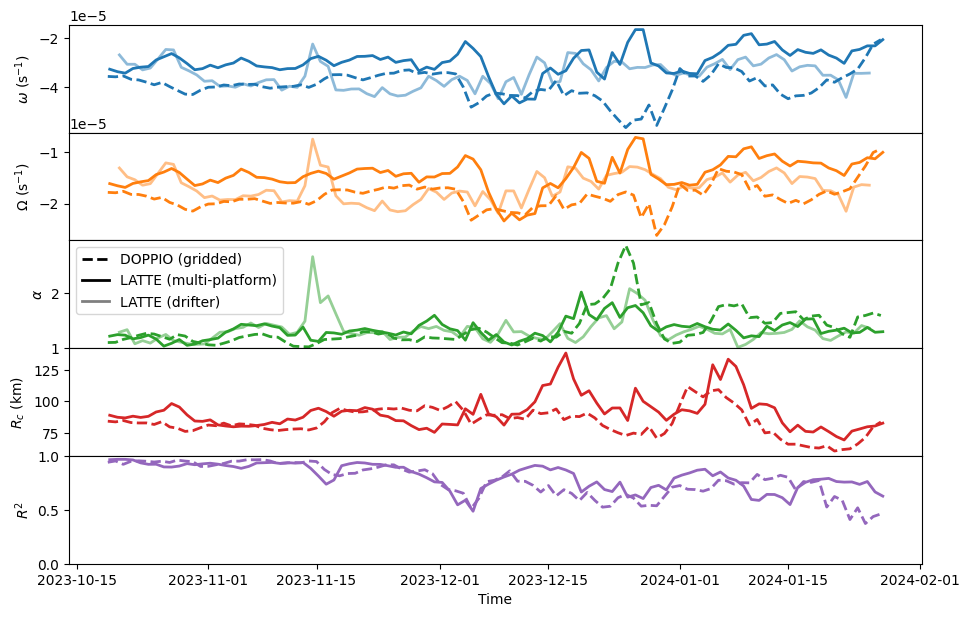

In [3]:
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(5, 1, figsize=(11,7), sharex=True)
lw = 2

styles = ['--', '-', '-']
for k, df in enumerate([df_res_doppio_num, df_res_latte_drifter_sat, df_res_latte_drifter]):

    alpha = 1 if k < 2 else .5

    axs[0].plot(df.time, df.w, color=clrs(0), lw=lw, ls=styles[k], alpha=alpha)
    axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')
    
    axs[1].plot(df.time, df.Omega, color=clrs(1), lw=lw, ls=styles[k], alpha=alpha)
    axs[1].set_ylabel(r'$\Omega$ (s$^{-1}$)')
    
    axs[2].plot(df.time, df.alpha, color=clrs(2), lw=lw, ls=styles[k], alpha=alpha)
    axs[2].set_ylabel(r'$\alpha$')
    axs[2].set_ylim(1, None)
    
    axs[3].plot(df.time, df.Rc/1e3, color=clrs(3), lw=lw, ls=styles[k], alpha=alpha)
    axs[3].set_ylabel(r'$R_c$ (km)')
    
    axs[4].plot(df.time, df.R2, color=clrs(4), lw=lw, ls=styles[k], alpha=alpha)
    axs[4].set_ylabel(r'$R^2$')
    axs[4].set_xlabel('Time')
    axs[4].set_ylim(0,1)

axs[2].plot([np.nan, np.nan], [np.nan, np.nan], lw=lw, ls='--', label='DOPPIO (gridded)', color='k')
axs[2].plot([np.nan, np.nan], [np.nan, np.nan], lw=lw, ls='-', label='LATTE (multi-platform)', color='k')
axs[2].plot([np.nan, np.nan], [np.nan, np.nan], lw=lw, ls='-', label='LATTE (drifter)', color='k', alpha=.5)
axs[2].legend(loc='upper left')

fig.subplots_adjust(hspace=0)


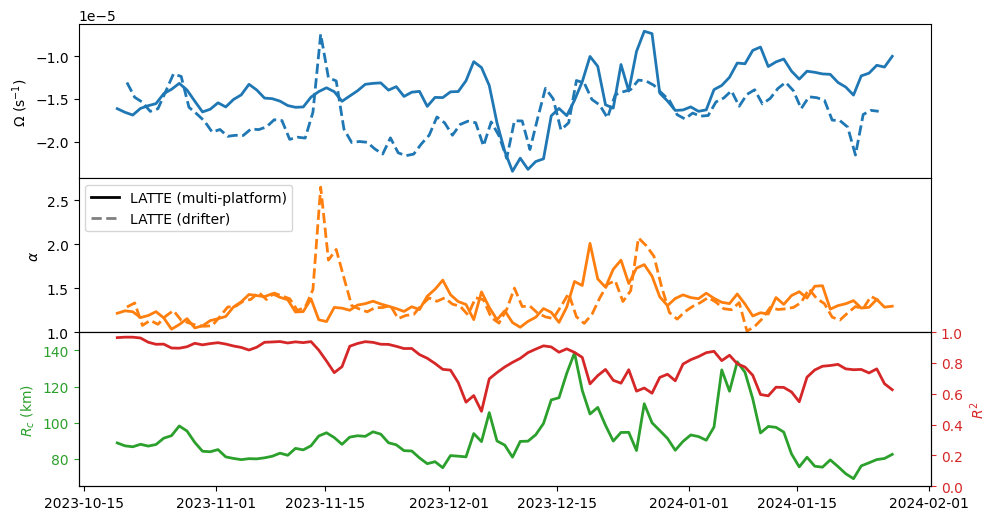

In [17]:
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(3, 1, figsize=(11,6), sharex=True)

lw = 2
alpha = 1
styles = ['-', '--']

for k, df in enumerate([df_res_latte_drifter_sat, df_res_latte_drifter]):

    # --- Omega ---
    axs[0].plot(df.time, df.Omega, color=clrs(0), lw=lw, ls=styles[k], alpha=alpha)
    axs[0].set_ylabel(r'$\Omega$ (s$^{-1}$)')

    # --- alpha ---
    axs[1].plot(df.time, df.alpha, color=clrs(1), lw=lw, ls=styles[k], alpha=alpha)
    axs[1].set_ylabel(r'$\alpha$')
    axs[1].set_ylim(1, None)
    if k ==0:
        # --- Rc (left axis) ---
        axs[2].plot(df.time, df.Rc/1e3, color=clrs(2), lw=lw, ls=styles[k], alpha=alpha)
    
        # --- R2 (right axis) ---
        ax2 = axs[2].twinx()
        ax2.plot(df.time, df.R2, color=clrs(3), lw=lw, ls=styles[k], alpha=alpha)

# labels
axs[2].set_ylabel(r'$R_c$ (km)', color=clrs(2))
ax2.set_ylabel(r'$R^2$', color=clrs(3))

# tick colours
axs[2].tick_params(axis='y', colors=clrs(2))
ax2.tick_params(axis='y', colors=clrs(3))

ax2.set_ylim(0, 1)

# legend (unchanged trick)
axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=lw, ls='-', label='LATTE (multi-platform)', color='k')
axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=lw, ls='--', label='LATTE (drifter)', color='k', alpha=.5)
axs[1].legend(loc='upper left')

axs[1].set_ylim(1, 2.75)
axs[2].set_ylim(65, 150)

fig.subplots_adjust(hspace=0)

